# fastclimate

simplified climate model

In [1]:
# import matplotlib for plotting:
import matplotlib.pyplot as plt
# import function to run fastclimate:
from fastclimate import run_fastclimate

## model parameters

define the model parameters

In [2]:
model_parameters = {
    #  model run time (years):
    'tmax': 15,
    #  plot from this year:
    'plotstart': 13,
    #  plot this many years (years):
    'plotyears': 2,
    #  this model run will be compared with one
    #  other previous run:
    'comparewith': '100yearstandard.json',
    # offset initial conditions ...
    # initial temperature offsets (^oC)
    # (Tocean<freezing will be adjusted):
    'toffset': 0,
    # initial ice thickness offsets (m)
    # (hi<0 will be adjusted) 13.65 is threshold:
    'iceoffset': 0,
    # Simulated CO2 concentration time today's concentration (1=today):
    'co2': 1.0,
    # albedos ...
    # albedo of snow-covered land surfaces (except Antarctica):
    'albsnow': 0.73,
    # albedo of surface in Antarctica (higher because no trees):
    'albsnowant': 0.85,
    # typical non-ice land albedo:
    'albbare': 0.15,
    # ice-free ocean albedo:
    'albonoice': 0.08,
    # thick ice albedo cold season albedo:
    'alboicewin': 0.75,
    # thick ice summer albedo:
    'alboicesum': 0.65,
    # atmosphere and cloud albedo:
    'albatm': 0.26,
    # atmosphere and cloud sw absorption parameter:
    'absair': 0.18,
    # horizontal advection (ocean latitude variations set in intialization
    # arrays ...
    # horizontal advection parameter for atmosphere  (J lat2/s/m2/K):
    'Kha': 1100,
    # horizontal advection parameter for ocean (J lat2/s/m2/K)
    # (doesn't depend on mixed layer depth):
    'Kho1': 300,
    # efficiency ice transfer factor applied to all lats (m3K/J)
    # used to apply Khom to ice:
    'Khicefactor': 3.3e-08,
    # Vertical advection (convection) ...
    # lower cutoff for deltaT for convective transfer (K):
    'Va1': 26.0,
    # vertical advection transfer coefficient (J/s/m2/K):
    'Kva': 35.0,
    # ice parameters (albedo defined above) ...
    # thick ice vertical heat transfer coefficient
    # (J/s/m/K) includes snow + lead effect:
    'Kicethick': 0.8,
    # thin ice vertical heat transfer coefficient (J/s/m/K)
    # assume no snow:
    'Kicethin': 2.0,
    # no albedo or heat heat transfer coefficient changes at
    # thicker ice (m):
    'zicethick': 0.5,
    # equivalent open water in pack ice:
    'leadfraction': .05,
    # radiation parameters ...
    # solar constant (J/s/m2):
    'sc': 1365,
    # top upper (going up) atmospheric emissivity
    # (Close to 500 mb?):
    'epsua1': 0.90,
    # bottom upper (going down) atmospheric emissivity
    # (higher with clouds):
    'epsba1': 1.22,
    # total atmosphere LW absorptivity (should equal epsua1?):
    'epsa1': 0.945,
    # surface/ABL emmissivity:
    'epssfc': 1.0,
    # Surface/ABL heat capacities ...
    # ABL heat capacity with includes soil (J/m2/K)  Higher than
    # actual to prevent numerical instability:
    'Csl': 4e6,
    # ABL heat capacity alone (or with snow surface) (J/m2/K):
    'Css': 2e6,
    # Land snow parameters
    # (between these temps albedo and heat capacity transition
    #  from snow to bare values) ...
    # Temperature below which surface assumed totally covered
    # with snow:
    'Tsnowtotal':  269,
    # Temperature above which surface assumed totally snow-free:
    'Tsnowstart':  278,
    # Ocean parameters ...
    # ocean mixed layer depth (m):
    'hocean': 50,
    # ocean flux from below mixed layer (J/s/m2) (not conserved):
    'qocean1': 2,
    # timestep (days):
    'dtday': 1,
    # save every savestep points for plotting:
    'savestep': 10
}

## run the model

run the model and get the result

In [3]:
# run fastclimate and get result:
result = run_fastclimate(model_parameters)

In [4]:
# the model result contains these items:
print(result.keys())

dict_keys(['swtop', 'doy', 'l', 'cnplot', 'cnit', 'nit', 'ttp', 'tt', 'TT', 'TTsland', 'TTocean', 'TTsocean', 'TTsavg', 'Qs', 'Qa', 'Qatm', 'Qice', 'Qall', 'Qmelt', 'Albocean', 'Lw', 'Alpha', 'Hi'])


## plot the results

create plots of the model results

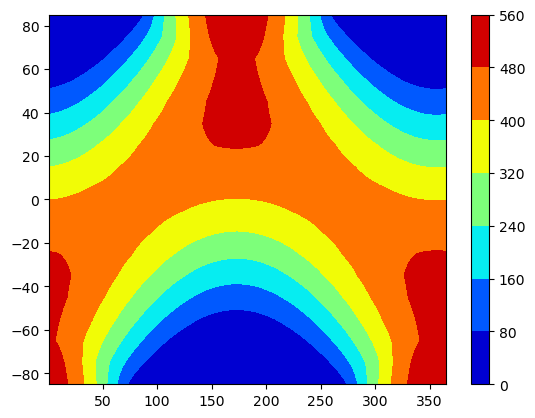

In [5]:
# create a contour plot of swtop:
x = result['doy']
y = result['l']
z = result['swtop']
plt.contourf(x, y, z, cmap='jet')
plt.colorbar()

In [6]:
# latitude values are stored in 'l':
print('* result contains', len(result['l']), 'latitude values:')
print(result['l'])

* result contains 18 latitude values:
[-85. -75. -65. -55. -45. -35. -25. -15.  -5.   5.  15.  25.  35.  45.
  55.  65.  75.  85.]


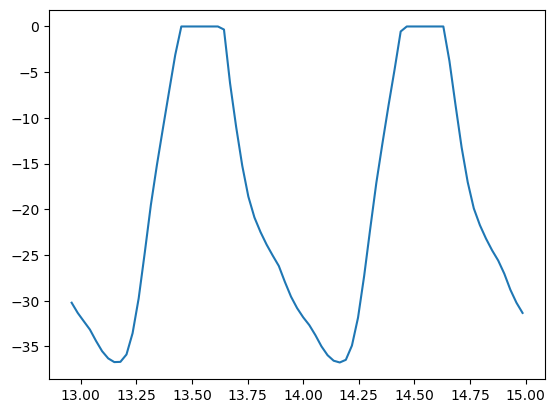

In [7]:
# plot time series of surface temperature for 85°N:
x = result['ttp']
y = result['TTsavg'][-1][result['nit']]
plt.plot(x, y)